In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

# Lotka-Volterra

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dt = 0.3 # 0.3 showed effect okay

train_interpolation_dts = np.logspace(-3, np.log10(dt), 11).tolist()[:-1] + [None]
noise_levels = np.logspace(-3, 0, 10).tolist()

t_span = (0, 50)
t_span_train = (0, 20)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 42,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dt, 't_span_train': t_span_train,
    'train_interpolation_dt': train_interpolation_dts,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config, generate_prediction=True)

rows are noise_level. there are 10 rows.
columns are train_interpolation_dt. there are 11 columns.
step 1 of 10


100%|██████████| 11/11 [00:04<00:00,  2.44it/s]


step 2 of 10


100%|██████████| 11/11 [00:03<00:00,  2.76it/s]


step 3 of 10


...

100%|██████████| 11/11 [00:01<00:00,  5.78it/s]


step 9 of 10


100%|██████████| 11/11 [00:06<00:00,  1.71it/s]


step 10 of 10


100%|██████████| 11/11 [00:08<00:00,  1.30it/s]


rows are noise_level. there are 10 rows.
columns are train_interpolation_dt. there are 11 columns.


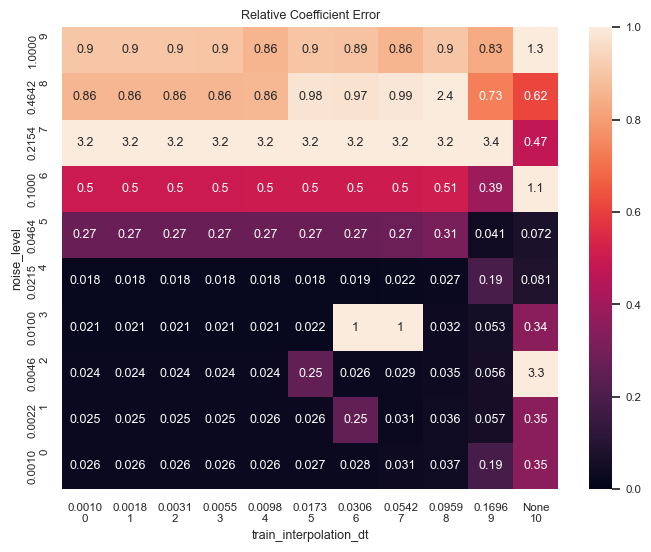

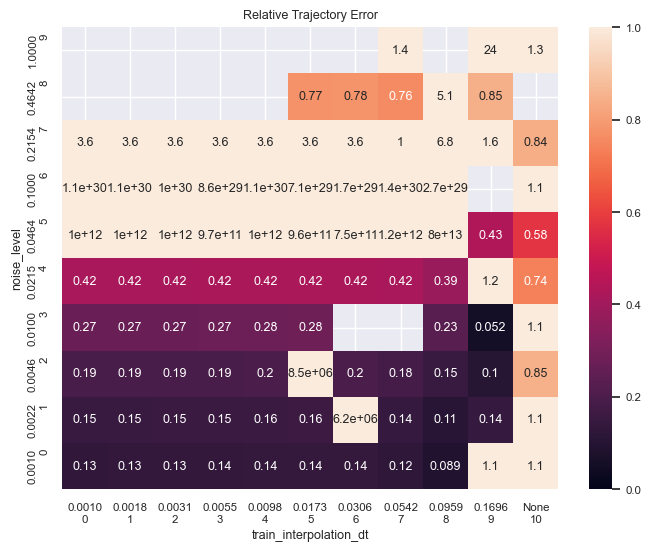

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 0.24423 1 + 1.08562 x0 + -0.08689 x1 + -0.35323 x0 x1 
x1' = + -0.39853 1 


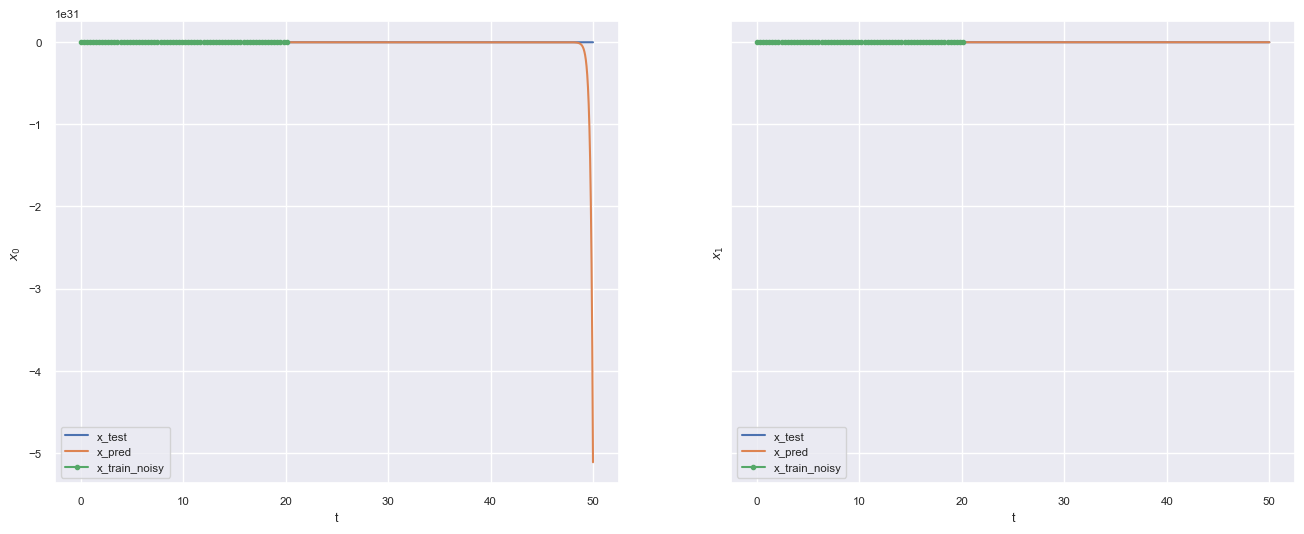

In [4]:
display_single_result(experiment_config, results, 8, 6, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

# Van der Pol

In [5]:
# van_der_pol_oscillator_rhs = generate_van_der_pol_oscillator_rhs(*default_params['van_der_pol_oscillator'])
# true_coeffs = generate_van_der_pol_oscillator_true_coefficients(*default_params['van_der_pol_oscillator'])
# x0 = default_x0['van_der_pol_oscillator']

# train_interpolation_dts = np.logspace(-3, -1, 11).tolist()
# noise_levels = np.logspace(-3, 0, 10).tolist()

# t_span = (0, 50)
# t_span_train = (0, 15)
# dt = 0.1

# experiment_config2 = {
#     # define fixed parameters
#     'rhs': van_der_pol_oscillator_rhs,
#     'derivative_approximation': dxdt_finite_difference,
#     't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
#     'np_seed': 0,
#     'true_coeffs': true_coeffs,
#     # define parameters that can be lists
#     'x0': x0, 'noise_level': noise_levels,
#     't_eval_train': None, 'dt_train': dt, 't_span_train': t_span_train,
#     'train_interpolation_dt': train_interpolation_dts,
#     'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
# }

# results2 = run_experiment(experiment_config2, generate_prediction=True)

In [6]:
# plot_heatmaps(experiment_config2, results2)

In [7]:
# display_single_result(experiment_config2, results2, 3, 6, keys_to_display=['x_train', 'x_train_noisy'])

In [8]:
duffing_oscillator_rhs = generate_duffing_oscillator_rhs(*default_params['duffing_oscillator'])
true_coeffs = generate_duffing_oscillator_true_coefficients(*default_params['duffing_oscillator'])
x0 = default_x0['duffing_oscillator']

dt = 0.2

train_interpolation_dts = np.logspace(-3, np.log10(dt), 11).tolist()[:-1] + [None]
noise_levels = np.logspace(-3, 0, 10).tolist()

t_span = (0, 50)
t_span_train = (0, 15)

experiment_config2 = {
    # define fixed parameters
    'rhs': duffing_oscillator_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 0,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dt, 't_span_train': t_span_train,
    'train_interpolation_dt': train_interpolation_dts,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results2 = run_experiment(experiment_config2, generate_prediction=True)

rows are noise_level. there are 10 rows.
columns are train_interpolation_dt. there are 11 columns.
step 1 of 10


100%|██████████| 11/11 [00:02<00:00,  4.14it/s]


step 2 of 10


100%|██████████| 11/11 [00:02<00:00,  3.88it/s]


step 3 of 10


...

 82%|████████▏ | 9/11 [00:42<00:09,  4.98s/it]

timeout occurred in solve_ivp_with_timeout


100%|██████████| 11/11 [00:48<00:00,  4.42s/it]


timeout occurred in solve_ivp_with_timeout
step 10 of 10


100%|██████████| 11/11 [00:06<00:00,  1.61it/s]


rows are noise_level. there are 10 rows.
columns are train_interpolation_dt. there are 11 columns.


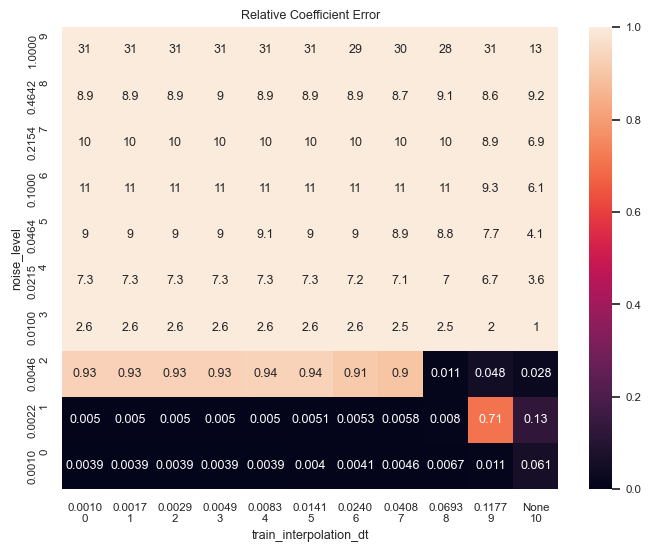

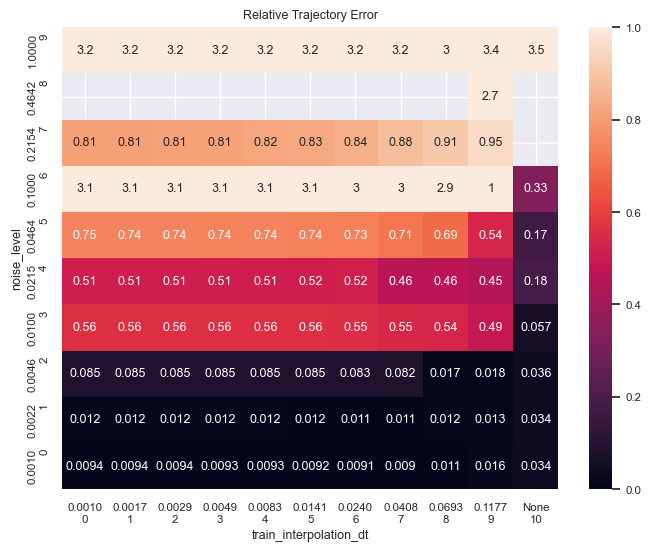

In [9]:
plot_heatmaps(experiment_config2, results2)

x0' = + 0.99830 x1 + -0.11968 x0 x1 + 0.17704 x0^2 x1 + 0.12419 x0 x1^2 + 0.19113 x0^3 x1 + 0.45535 x0 x1^3 + -0.06312 x1^4 + -0.21314 x0^4 x1 + -0.17953 x0^3 x1^2 + -0.77923 x0^2 x1^3 
x1' = + 0.05890 1 + -0.08019 x0 + -0.17354 x1 + -0.24861 x0^2 + -0.15393 x0 x1 + -0.92828 x1^2 + -1.56792 x0^3 + 0.11580 x0^2 x1 + -0.58661 x0 x1^2 + 0.74118 x1^3 + 0.16394 x0^4 + 0.20065 x0^3 x1 + 1.12967 x0^2 x1^2 + 0.75408 x0 x1^3 + 1.85738 x1^4 + 0.50909 x0^5 + -0.27244 x0^4 x1 + 0.54275 x0^3 x1^2 + -1.06020 x0^2 x1^3 + -0.30492 x0 x1^4 + -1.75969 x1^5 


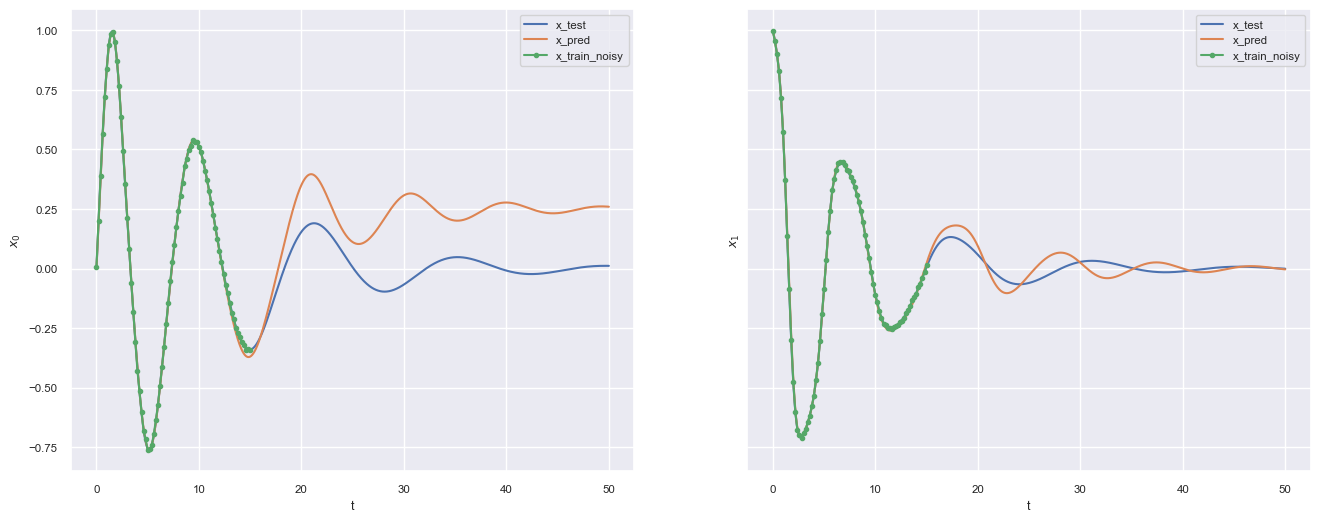

In [10]:
display_single_result(experiment_config2, results2, 7, 3, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])